In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder,OneHotEncoder

In [15]:
df=pd.read_csv('adult.csv')

In [16]:
df.shape

(32561, 15)

In [17]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [19]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


According to the information from the data, it has 6 columns of numerical type and 9 categorical data columns

In [20]:
# replacing the ? present in the dataset
df.replace('?', np.nan)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [21]:
## Checking for missing values
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

#### Hence there are no missing values in the dataset to apply replace or  imputation technique

##### Scaling 
Scaling is basically carreid out on the numerical columns to bring the data in particular range

In [29]:
numerical_col= df.select_dtypes(include='int64').columns
numerical_col

Index(['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss',
       'hours_per_week'],
      dtype='object')

In [39]:
std_sca=StandardScaler()
min_max=MinMaxScaler()

In [41]:
#Applying Standard Scaler Technique On Numerical Columns in the dataset
#Take a Copy of dataset to preserve the original dataset
Scaled_data = df.copy() 
Scaled_data[numerical_col] =std_sca.fit_transform(Scaled_data[numerical_col]) 
Scaled_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.030671,State-gov,-1.063611,Bachelors,1.134739,Never-married,Adm-clerical,Not-in-family,White,Male,0.148453,-0.21666,-0.035429,United-States,<=50K
1,0.837109,Self-emp-not-inc,-1.008707,Bachelors,1.134739,Married-civ-spouse,Exec-managerial,Husband,White,Male,-0.145920,-0.21666,-2.222153,United-States,<=50K
2,-0.042642,Private,0.245079,HS-grad,-0.420060,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
3,1.057047,Private,0.425801,11th,-1.197459,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.145920,-0.21666,-0.035429,United-States,<=50K
4,-0.775768,Private,1.408176,Bachelors,1.134739,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.145920,-0.21666,-0.035429,Cuba,<=50K


In [43]:
## Applying Minmax Scaler technique to the numerical columns in the dataset
## Here also twe take a copy of the original dataset to keep the original dataset secure
minmax_data=df.copy()
minmax_data[numerical_col]=min_max.fit_transform(minmax_data[numerical_col])
minmax_data.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,0.301370,State-gov,0.044302,Bachelors,0.800000,Never-married,Adm-clerical,Not-in-family,White,Male,0.02174,0.0,0.397959,United-States,<=50K
1,0.452055,Self-emp-not-inc,0.048238,Bachelors,0.800000,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.00000,0.0,0.122449,United-States,<=50K
2,0.287671,Private,0.138113,HS-grad,0.533333,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.00000,0.0,0.397959,United-States,<=50K
3,0.493151,Private,0.151068,11th,0.400000,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.00000,0.0,0.397959,United-States,<=50K
4,0.150685,Private,0.221488,Bachelors,0.800000,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.00000,0.0,0.397959,Cuba,<=50K


### Scaling
###### 1. Standard Scaler:
It is also called as Standardization. It transforms data to have a mean value of 0 and Standard devation of 1. it ranges the values (-3,+3).
It is the best method applied when the data is normally distributed and applied to algorithms which assume the guassian distribution of the data such as:
Logistic Regression
Linear Regression
Principal Component Analysis(PCA)

###### 2. MinMax Scaler
Also Known As Normalization. It scaled data to a particular range of [0,1]. 
Works best for distance based Algorithms such as 
KNN -K Nearest Neighbour
K-Means Clustering



### 2. Encoding Techniques:

In [44]:
## Applying One=Hot Encoding technique to the categorical variables with less than 5 categories

In [46]:
# firstly we find the categorical column names in the given dataset
cate_col= df.select_dtypes(include='object').columns
cate_col

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'sex', 'native_country', 'income'],
      dtype='object')

In [52]:
# check the number of categories in each column 
df.nunique()

age                  73
workclass             9
fnlwgt            21648
education            16
education_num        16
marital_status        7
occupation           15
relationship          6
race                  5
sex                   2
capital_gain        119
capital_loss         92
hours_per_week       94
native_country       42
income                2
dtype: int64

In [49]:
#Nextly we find names Of The Columns that have less than 5 Categories
new_cat_col=[col for col in cate_col
if df[col].nunique() < 5 ]
new_cat_col

['sex', 'income']

In [53]:
## Applying One Hot Encoding technique by getting dummies
df_new = df.copy()
df_new = pd.get_dummies(df, columns = new_cat_col) 
df_new.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,2174,0,40,United-States,False,True,True,False
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,13,United-States,False,True,True,False
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,40,United-States,False,True,True,False
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,40,United-States,False,True,True,False
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,0,0,40,Cuba,True,False,True,False


 Labelling is done onto the dataset to convert the categoical variables into the numerical ones
Here the given data set contains 2 nominal columns that are sex and income
and they are converted to the boolean category

### Next Applying LabelEncoder to the remaining categorical variables

In [56]:
# we need to select dataset with more than 5 categories 
## Applying basic data exploration such as finding missing values, Statistcal summary and data types to this dataset

In [60]:
le= LabelEncoder()

In [61]:
# firstly we find the categorical column names in the given dataset
cate_col= df_new.select_dtypes(include='object').columns
cate_col

Index(['workclass', 'education', 'marital_status', 'occupation',
       'relationship', 'race', 'native_country'],
      dtype='object')

In [69]:
### selecting columns with more than 5 categories
for col in cate_col:
    if df_new[col].nunique() >= 5 : 
        df_new[col] = le.fit_transform(df_new[col]) 
        ## Transformin the columns
df_new.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,False,True,True,False
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,False,True,True,False
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,False,True,True,False
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,False,True,True,False
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,True,False,True,False


In [64]:
## Nextly find the  missing values in the dataset
df_new.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
sex_ Female       0
sex_ Male         0
income_ <=50K     0
income_ >50K      0
dtype: int64

In [65]:
## Gwtting the statistical summary
df_new.describe()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country
count,32561.000000,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,3.868892,1.897784e+05,10.298210,10.080679,2.611836,6.572740,1.446362,3.665858,1077.648844,87.303830,40.437456,36.718866
std,13.640433,1.455960,1.055500e+05,3.870264,2.572720,1.506222,4.228857,1.606771,0.848806,7385.292085,402.960219,12.347429,7.823782
min,17.000000,0.000000,1.228500e+04,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,4.000000,1.178270e+05,9.000000,9.000000,2.000000,3.000000,0.000000,4.000000,0.000000,0.000000,40.000000,39.000000
50%,37.000000,4.000000,1.783560e+05,11.000000,10.000000,2.000000,7.000000,1.000000,4.000000,0.000000,0.000000,40.000000,39.000000
75%,48.000000,4.000000,2.370510e+05,12.000000,12.000000,4.000000,10.000000,3.000000,4.000000,0.000000,0.000000,45.000000,39.000000
max,90.000000,8.000000,1.484705e+06,15.000000,16.000000,6.000000,14.000000,5.000000,4.000000,99999.000000,4356.000000,99.000000,41.000000


In [68]:
### Checking the datatype of each column
df_new.dtypes

age               int64
workclass         int64
fnlwgt            int64
education         int64
education_num     int64
marital_status    int64
occupation        int64
relationship      int64
race              int64
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country    int64
sex_ Female        bool
sex_ Male          bool
income_ <=50K      bool
income_ >50K       bool
dtype: object

In [70]:
# here the remaining categorical vcolumns are converted to numerical type by application of labelEncoder to the dataset

#### Pros and cons of One Hot Encoding And label encoding techniques

### 1.One Hot Encoding 

##### pros:
. Prevents the model from assuming any kind of order or priority between the categories.
. It is simple and easy and ideal for nominal categorical variables which cannot be ranked/ordered
. it is suitable and Works well with  many algorithms like Logistic Regression, Random Forests, Neural Networks.


##### Cons:
. It increases the dimensionality ,if a feature has many unique categiories,it creates vast number of new columns.
. It creates  curse of dimensionality because increased column count slow down the training time and model performance is also reduced.
. It can also introduce multicolinearity.
 

### 2. Label Encoding



#### Pros:
. It is simple to use and can be fast applied
. It doesnot increase the dimensionality of the dataset and is memory efficient
. It is mostly useful when the categorical variables are of ordinal type(which can be ranked or ordered)
. It is compatible with most of the algorithms such as Decision Tree, Random Forest, XG Boost which can handle numerical ranking

##### Cons:
. It doesnot work well with Linear models such as Linear Regression, Logistic Regression,KNN
. It may mislead ML Algorithms if categories are nominal (no order) and it may treat them as ordinal



### 3. Feature Engineering

In [71]:
## Task is given to Create atleast 2 new features that could be beneficial for the model. 
## Explain the rationale behind choice.

In [73]:
df_new.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,False,True,True,False
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,False,True,True,False
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,False,True,True,False
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,False,True,True,False
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,True,False,True,False


In [74]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [79]:
## Getting the true picture of capital wealth
df_new['Net_capital']= df_new['capital_gain']-df_new['capital_loss']
df_new.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,Net_capital
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,False,True,True,False,2174
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,False,True,True,False,0
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,False,True,True,False,0
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,False,True,True,False,0
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,True,False,True,False,0


In [80]:
### Next for maritlal Status we find all the categories in the marital status column
df['marital_status'].unique()

array([' Never-married', ' Married-civ-spouse', ' Divorced',
       ' Married-spouse-absent', ' Separated', ' Married-AF-spouse',
       ' Widowed'], dtype=object)

In [81]:
df_new['married'] = df_new['marital_status'].apply(lambda x: 1 if x in ['Married-civ-spouse', 'Married-AF-spouse'] else 0)
df_new.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,Net_capital,married
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,False,True,True,False,2174,0
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,False,True,True,False,0,0
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,False,True,True,False,0,0
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,False,True,True,False,0,0
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,True,False,True,False,0,0


In [99]:
#Find Skewness Of Each Columns
skewness = df_new.skew().sort_values(ascending=False) 
print("Skewness of numerical columns:\n",skewness)

Skewness of numerical columns:
 Net_capital       11.871934
capital_loss       4.594629
capital_gain       3.028219
fnlwgt             1.446980
income_ >50K       1.212430
relationship       0.786818
sex_ Female        0.719293
age                0.558743
hours_per_week     0.227643
occupation         0.114583
married            0.000000
marital_status    -0.013508
education_num     -0.311676
sex_ Male         -0.719293
workclass         -0.752024
education         -0.934042
income_ <=50K     -1.212430
race              -2.435386
native_country    -3.658303
dtype: float64


In [103]:
# Apply log transformation to skewed numerical feature
# take a  numerical feature
skewed_feature = 'capital_gain'  


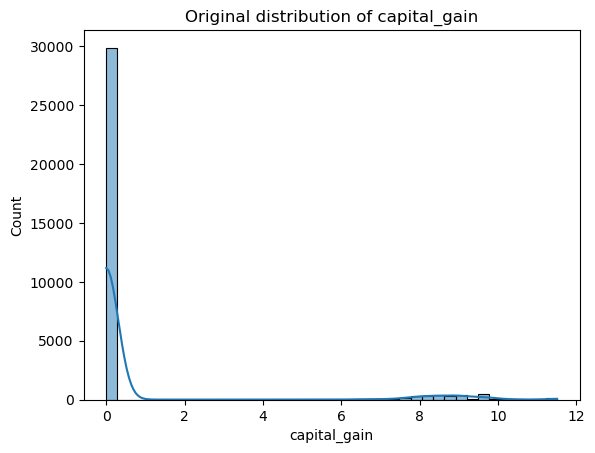

In [104]:
 #Plotting Histogram plot of capital_gain Column
sns.histplot(df['capital_gain'], bins=40, kde=True)
plt.title(f'Original distribution of capital_gain')
plt.show()

In [105]:
#Log Transformation Of Capital_gain Column
df_new['capital_gain_log'] = np.log1p(df_new['capital_gain']) 
df_new.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,Net_capital,married,capital_gain_log
0,39,7,77516,9,13,4,1,1,4,1.15107,0,40,39,False,True,True,False,2174,0,0.765965
1,50,6,83311,9,13,2,4,0,4,0.00000,0,13,39,False,True,True,False,0,0,0.000000
2,38,4,215646,11,9,0,6,1,4,0.00000,0,40,39,False,True,True,False,0,0,0.000000
3,53,4,234721,1,7,2,6,0,2,0.00000,0,40,39,False,True,True,False,0,0,0.000000
4,28,4,338409,9,13,2,10,5,2,0.00000,0,40,5,True,False,True,False,0,0,0.000000


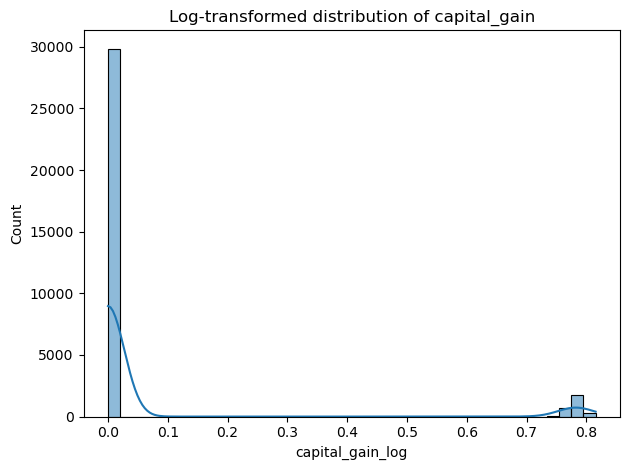

In [106]:
### Now plotting histogram plot of capital gain log
sns.histplot(df_new['capital_gain_log'], bins=40, kde=True) 
plt.title(f'Log-transformed distribution of capital_gain')
plt.tight_layout()
plt.show()

### Isolation forest and pps score

In [109]:
from sklearn.ensemble import IsolationForest

In [112]:
isolation_forest = IsolationForest(n_estimators=100,contamination=0.05)
outlier_labels = isolation_forest.fit_predict(df_new[numerical_col])
data = df_new[outlier_labels == 1]

In [115]:
#### PPS (Predictive Power Score)
!pip install -U ppscore
import ppscore as pps

In [116]:
# PPS analysis
pps_matrix = pps.matrix(data)
print(pps_matrix)

                    x                 y   ppscore                case  \
0                 age               age  1.000000      predict_itself   
1                 age         workclass  0.000000          regression   
2                 age            fnlwgt  0.000000          regression   
3                 age         education  0.000000          regression   
4                 age     education_num  0.000000          regression   
..                ...               ...       ...                 ...   
395  capital_gain_log     income_ <=50K  0.245801      classification   
396  capital_gain_log      income_ >50K  0.245801      classification   
397  capital_gain_log       Net_capital  0.854899          regression   
398  capital_gain_log           married  0.000000  target_is_constant   
399  capital_gain_log  capital_gain_log  1.000000      predict_itself   

     is_valid_score               metric  baseline_score   model_score  \
0              True                 None        0